# Pattern

As explained RFC 9156 QMIN, in it's most primitive way, opens a new attack vactor as well as a degredation in performance. This is due to the fact that the resolve will perform one DNS request per label. In some cases, where one authoritive DNS server serves multiple labels of the query, the amount of request is increased compared to the traditional DNS method.

#### E.G.:
Let's assume we query the domain a.b.c.d.e.f.g.h.example.com and we have one authoritive DNS server that serves as domain from h.example.com to a.b.c.d.e.f.g.h.example.com. <br>
With the traditional way of DNS querring the recursive resolver would get a redirection from the authoritive DNS of example.com towoard our authoritive DNS server. The RR would than send the FQDN to said to our DNS server and it would answer the request. In this case the name resolution would be completed in one request (if we just look at what's happening on our dns server). <br>
With QMIN the RR would send 8 requests, each containing one label more than the previous. <br><br>

This does not only degrade performance but also opens a attack vector for applification based DDoS attack to both the RR and the authoritive server.

### Solution

To mitigate this Problem RFC 9156 proposes to send multiple labels per request. How many would be defined by two bounds: <br>
MINIMISE_ONE_LAB: defines how many queries will be send with only one new Label <br>
MAX_MINIMISE_COUNT: defines how many requests are allow to be send in total (incliding MINIMISE_ONE_LAB). If there are more labels than this, the remaining labels after MINIMISE_ONE_LAB will be split onto (MAX_MINIMISE_COUNT - MINIMISE_ONE_LAB) requests. If there is a remainder the remaining labels will be added one each going from the bottom most label.

#### E.G.:
using the previous example. <br>
MINIMISE_ONE_LAB = 3 <br>
MAX_MINIMISE_COUNT = 5 <br><br>

The resultion request pattern would look like this: a.b.c.d|e.f.g|h|example|com<br>
Each bar ("|") indicated where a new request would be send. Our DNS server would now observe 3 incoming requests, which is still more than the one from the traditional querry method but less compared to primitiv QMIN.


## Note
One thing that should be obvious and is very important for this notebook is the fact that our DNS server happening after example.com. So if the RR hat set MINIMISE_ONE_LAB = 2 and MAX_MINIMISE_COUNT = 3 our DNS server would see one incoming request for a.b.c.d.e.f.g.h.example.com (just like with the traditional method.) <br>
This notebook is used to derive these two bound from the observed patterns. As the used DNS server most like didn't run on a root or TLD server we cannot observe that is happening on this levels. Meaning there can be RR that don't appear to use QMIN while in reality they but but only e.G. on the two top most labels. 
<br><br>
Furthermore this notebook assumes that these resolver implemented both these bounds as proposed in RFC 9156. Should they diviate from this by, e.g. using more than these two bounds, we cannot know about this and would therefore misinterpret the seen pattern.

In [1]:
import pandas as pd
import matplotlib as plt
import sys

results_path = "/home/Til/Downloads/result.parquet"
results = pd.read_parquet(results_path)
results = results[results["status"] > 0]

In [2]:
def get_bounds(pattern: str) -> (int, int, str):

    MINIMISE_ONE_LAB = 1
    MAX_MINIMISE_COUNT = 1

    id_label_placeholder = "*idToken*"

    leftmost_dot = pattern.find(".")
    leftmost_dot = leftmost_dot if leftmost_dot > -1 else sys.maxsize

    leftmost_bar = pattern.find("|")
    leftmost_bar = leftmost_bar if leftmost_bar > -1 else sys.maxsize


    # get the number of labels that were used for this run
    # adding one for the id label
    num_label = int(pattern[:(leftmost_dot if leftmost_dot < leftmost_bar else leftmost_bar)]) + 1

    # catch thos with no pattern (no qmin?)
    if pattern.find("|") is -1:
        return (0,0, str(num_label))

    pattern = pattern[::-1]
    
    curr_index = len(id_label_placeholder)

    for x in range(num_label - 1):
        if pattern[curr_index] == "|":
            MINIMISE_ONE_LAB += 1
            MAX_MINIMISE_COUNT += 1
        else:
            break
        curr_index += len(str(x + 1)) + 1
    
    # catch those that perform primitv qmin
    if curr_index is len(pattern): return (MINIMISE_ONE_LAB, MAX_MINIMISE_COUNT, ("1-" * MAX_MINIMISE_COUNT)[:-1])
    MINIMISE_ONE_LAB -= 1
    
    # catch those that perform qmin the primitve way until bound and then send rest in one request
    if pattern[curr_index:].find("|") is -1:
        MAX_MINIMISE_COUNT += 1
        return (MINIMISE_ONE_LAB, MAX_MINIMISE_COUNT - 1, "1-" * MINIMISE_ONE_LAB + str(num_label - MINIMISE_ONE_LAB))
    
    MAX_MINIMISE_COUNT += pattern[curr_index:].count("|")

    label_pattern = "1-" * MINIMISE_ONE_LAB

    for x in range(MAX_MINIMISE_COUNT - MINIMISE_ONE_LAB + 1):
        next_bar = pattern[curr_index:].find("|")
        if next_bar is -1: 
            label_pattern += str(pattern[curr_index:].count(".") + 1)
            break        
        label_pattern += str(pattern[curr_index:curr_index + next_bar].count(".") + 1) + "-"
        curr_index = curr_index + next_bar + 1

    return (MINIMISE_ONE_LAB, MAX_MINIMISE_COUNT, label_pattern)




In [6]:
outputs = []


for row in results.itertuples():
    for pat in row.res:
        tmp = pat[0]
        if not "." in tmp or not "." in tmp:
            continue
        bounds = get_bounds(tmp)
        outputs.append([row.resolver_ip, bounds[0], bounds[1], bounds[2]])

outputs_frame = pd.DataFrame(outputs, columns=["resolverIP", "MINIMISE_ONE_LAB", "MAX_MINIMISE_COUNT", "label_pattern"])
# outputs_frame.to_csv("pattern_analysis.csv", index=False)


<Axes: ylabel='label_pattern'>

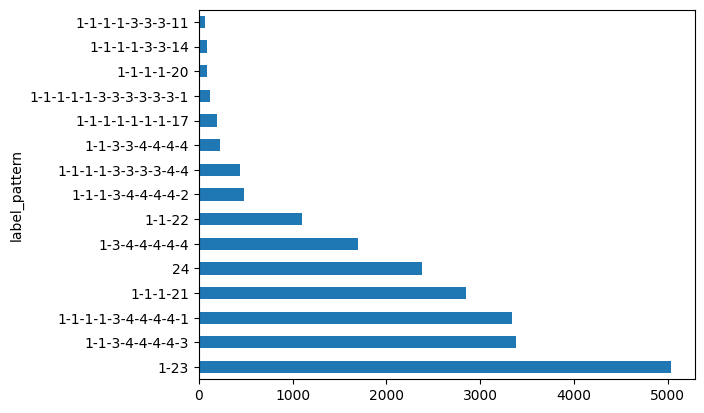

In [ ]:
#print(outputs_frame["label_pattern"].value_counts().head(15))
outputs_frame["label_pattern"].value_counts().head(15).plot.barh(stacked=True)

<Axes: ylabel='MINIMISE_ONE_LAB,MAX_MINIMISE_COUNT'>

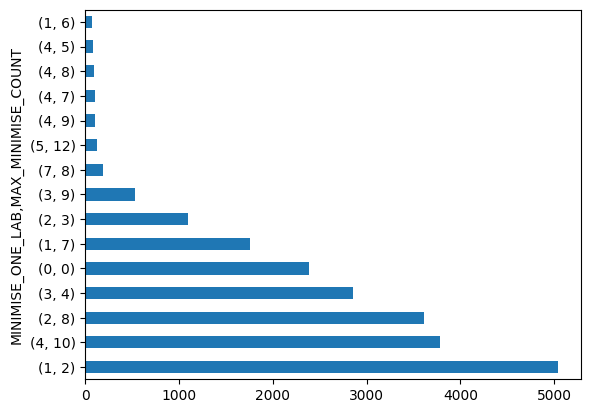

In [ ]:
outputs_frame[["MINIMISE_ONE_LAB", "MAX_MINIMISE_COUNT"]].value_counts().head(15).plot.barh(stacked=True)